In [1]:
# ============================================================
# Libraries and plot configuration
# ============================================================

import numpy as np
import pandas as pd
import warnings
from scipy.integrate import cumulative_simpson
from scipy.interpolate import interp1d
from scipy.linalg import inv, cho_factor, cho_solve
import matplotlib as mpl
import matplotlib.pyplot as plt
from gapp import gp
from gapp import covariance
import emcee
import multiprocessing as mp
from getdist import MCSamples, plots
from IPython.display import display, Math

mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Nimbus Roman"]
})

warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# ============================================================
# Load CC data
# ============================================================

cc_dat_path = "/home/brunowesley/projetos/GaPP/CC_Hz_data.txt"
df_cc = pd.read_csv(cc_dat_path, sep=r"\s+")

z_cc  = df_cc["z_cc"].to_numpy(float)      
H_cc  = df_cc["H_cc"].to_numpy(float)     
H_err = df_cc["H_cc_err"].to_numpy(float) 

# Speed of light in km/s
c = 299792.458

In [3]:
# ============================================================
# GP reconstruction
# ============================================================

zmin = 0.0
zmax = np.max(z_cc)

# Instantiate GP with Matérn 9/2 kernel
# This kernel assumes a high degree of smoothness (4-times differentiable) 
# but is less rigid than the SE, offering a more conservative
# estimation of uncertainties between data points.
g1 = gp.GaussianProcess(
    z_cc,
    H_cc,
    H_err,
    covfunction=covariance.Matern92,
    cXstar=(zmin, zmax, 200) 
)

rec1, theta1 = g1.gp(thetatrain="True")

zrec     = rec1[:, 0]
hzrec    = rec1[:, 1]
sighzrec = rec1[:, 2]

H0    = hzrec[0]
sigH0 = sighzrec[0]

print(f"H0 = {H0:.3f} ± {sigH0:.3f} km/s/Mpc")


Optimized hyperparameters:
theta = [128.3600827   2.2074549]
H0 = 68.475 ± 4.886 km/s/Mpc


  NIT   NF   F                       GTG
    0    1  1.503576259103126E+02   9.46222365E+00
    1    4  1.494348199146783E+02   3.87857128E-01
    2    9  1.488743345670516E+02   9.53986381E-04
    3   13  1.488613587332591E+02   9.87494668E-03
    4   18  1.488433716022028E+02   3.08539697E-03
    5   20  1.488404366501395E+02   4.49934346E-06
tnc: fscale = 185.024
    6   22  1.488404166583821E+02   3.67868606E-06
    7   24  1.488404093174272E+02   2.96908480E-09
tnc: fscale = 9415.52
tnc: |fn-fn-1] = 2.29712e-09 -> convergence
    8   26  1.488404093151301E+02   2.57862283E-12
tnc: Converged (|f_n-f_(n-1)| ~= 0)


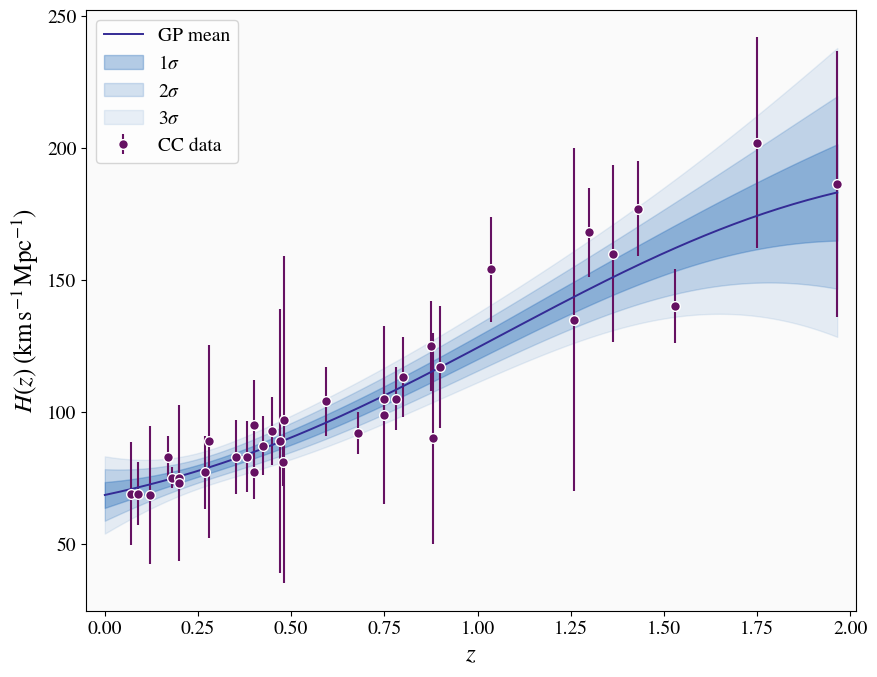

In [4]:
# =============================================================================
# Plotting: data + GP reconstruction
# =============================================================================

# Setting font style
plt.rcParams.update({
    "mathtext.fontset": "stix",
    "font.family": "STIXGeneral",
    "font.size": 14,
    "axes.labelsize": 18
})

# Figure size
fig, ax = plt.subplots(figsize=(9, 7))

# Axis labels
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$H(z)\;(\mathrm{km}\,\mathrm{s}^{-1}\,\mathrm{Mpc}^{-1})$")

# Axis limits
ax.set_xlim(zmin - 0.05, zmax + 0.05)

# Subtle background
ax.set_facecolor("#fafafa")

# Observational data
data_plot = ax.errorbar(
    z_cc,
    H_cc,
    yerr=H_err,
    fmt="o",
    markersize=7,
    markerfacecolor="#651162",
    markeredgecolor="white",
    ecolor="#651162",
    label=r"CC data"
)

# GP mean curve
mean_curve, = ax.plot(
    zrec,
    hzrec,
    color="#342B95",
    lw=1.4,
    label="GP mean"
)

# GP 1σ confidence region
band1 = ax.fill_between(
    zrec,
    hzrec - sighzrec,
    hzrec + sighzrec,
    color="#2a6fba",
    alpha=0.35,
    label=r"$1\sigma$"
)

# GP 2σ confidence region
band2 = ax.fill_between(
    zrec,
    hzrec - 2*sighzrec,
    hzrec + 2*sighzrec,
    color="#2a6fba",
    alpha=0.20,
    label=r"$2\sigma$"
)

# GP 3σ confidence region
band3 = ax.fill_between(
    zrec,
    hzrec - 3*sighzrec,
    hzrec + 3*sighzrec,
    color="#2a6fba",
    alpha=0.10,
    label=r"$3\sigma$"
)

# Legend
ax.legend(loc="best", frameon=True)

fig.tight_layout()

# Save and show figure
fig.savefig("Hz_CC_matern92_rec.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# ============================================================
# Construct full posterior predictive covariance matrix
# ============================================================

# The GP posterior covariance is:
#              C_gp = K** − K* (K + Σ)^(-1) K*^T
# Where:
# K   : Covariance between observed CC data points
# Σ   : Observational noise (diagonal matrix of H_err^2)
# K*  : Cross-covariance between reconstruction grid and data
# K** : Prior covariance at reconstruction points

# Note: The Matérn 9/2 kernel provides a more flexible 
# correlation structure compared to the SE kernel.


# Optimized hyperparameters
sigma_f, ell = theta1

# Matérn 9/2 covariance calculation
def kernel(x1, x2):
    """
    Matern 9/2 kernel:
    
        k(d) = σ_f^2 * exp(-3d/ℓ) * [1 + 3d/ℓ + (27d^2)/(7ℓ^2) + (18d^3)/(7ℓ^3) + (27d^4)/(35ℓ^4)]
    
    This kernel is 4-times differentiable, providing a balance between 
    the smoothness of the SE kernel and the flexibility needed for 
    cosmological reconstructions.
    """
    
    sigma_f, ell = theta1  # Optimized hyperparameters
    
    x1 = np.atleast_2d(x1).T
    x2 = np.atleast_2d(x2).T
    
    # Distance matrix d = |x1 - x2|
    d = np.abs(x1 - x2.T)
    
    # Dimensionless distance scaled by the length-scale ell
    arg = 3.0 * d / ell
    
    # Matern 9/2 polynomial terms
    term1 = 1.0 + arg
    term2 = (3.0/7.0) * arg**2
    term3 = (1.0/7.0) * arg**3
    term4 = (1.0/35.0) * arg**4
    
    poly = term1 + term2 + term3 + term4
    
    return sigma_f**2 * poly * np.exp(-arg)

# Re-evaluate the kernel matrices
K = kernel(z_cc, z_cc)
Sigma = np.diag(H_err**2)
K_y = K + Sigma
K_star = kernel(zrec, z_cc)
K_starstar = kernel(zrec, zrec)

# Posterior predictive covariance (Schur complement)
C_gp = K_starstar - K_star @ inv(K_y) @ K_star.T

# Add small jitter for numerical stability (regularization)
C_gp += 1e-8 * np.eye(len(C_gp))

In [6]:
# ============================================================
# Draw correlated GP realizations
# ============================================================

# We generate Monte Carlo realizations of H(z)
# to propagate full covariance into derived quantities.

mu = hzrec

L = np.linalg.cholesky(C_gp)

N_samples = 5000

# Each column corresponds to one GP realization
samples_H = mu[:, None] + L @ np.random.randn(len(zrec), N_samples)

In [7]:
# ============================================================
# Distance definitions
# ============================================================

# 1) Hubble distance
samples_DH = c / samples_H

# 2) Comoving transverse distance
integrand  = 1.0 / samples_H
samples_DM = c * cumulative_simpson(integrand, x=zrec, axis=0, initial=0.0)

# 3) Volume-averaged distance
samples_DV = (zrec[:, None] * samples_DM**2 * samples_DH)**(1/3)
samples_DV[0, :] = 0.0

In [8]:
# ============================================================
# Monte Carlo mean and covariance
# ============================================================

# Mean reconstruction
mean_DH = np.mean(samples_DH, axis=1)
mean_DM = np.mean(samples_DM, axis=1)
mean_DV = np.mean(samples_DV, axis=1)

# Standard deviation (1σ uncertainty)
sig_DH = np.std(samples_DH, axis=1)
sig_DM = np.std(samples_DM, axis=1)
sig_DV = np.std(samples_DV, axis=1)

# Full covariance matrices (redshift-redshift correlations)
cov_DH = np.cov(samples_DH)
cov_DM = np.cov(samples_DM)
cov_DV = np.cov(samples_DV)

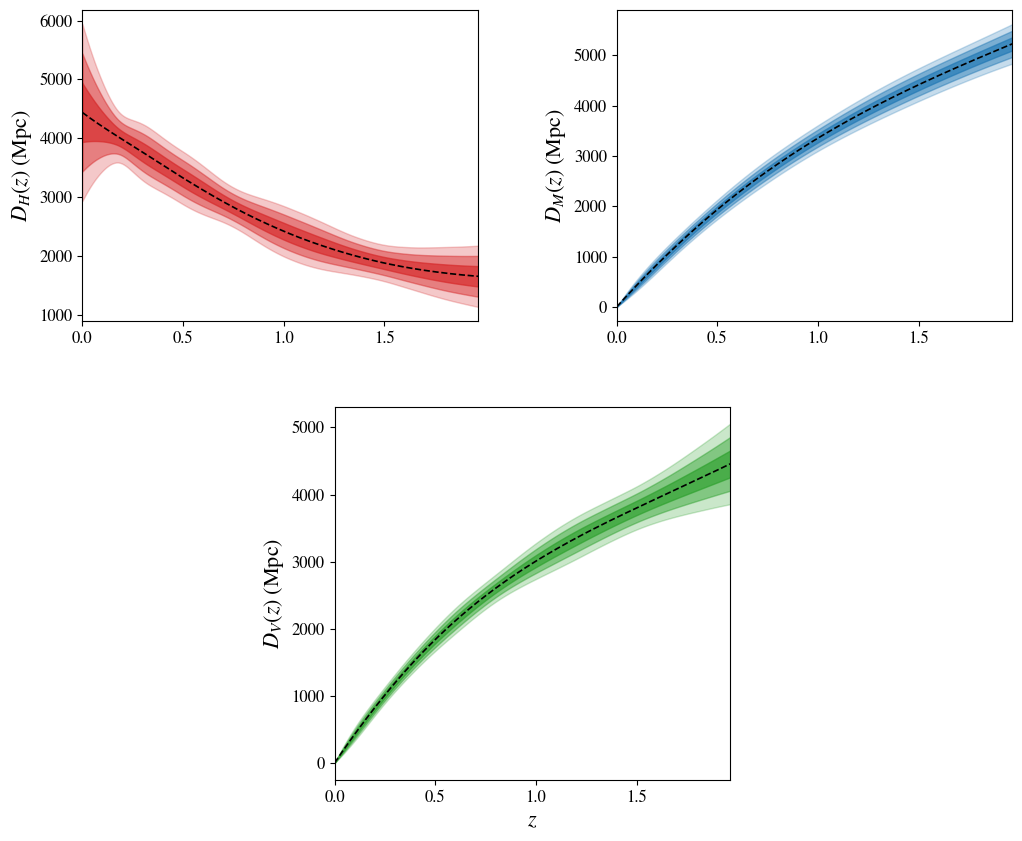

In [9]:
# =========================================================================
# Combined plot: DH(z), DM(z), DV(z) in custom layout (A, B, C)
# =========================================================================

fig = plt.figure(figsize=(12, 10))

# Create GridSpec: 2 rows, 2 columns
gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    height_ratios=[1, 1.2],  # bottom plot slightly taller
    hspace=0.25,
    wspace=0.35
)

# Axes definition
ax_DH = fig.add_subplot(gs[0, 0])   # Plot A
ax_DM = fig.add_subplot(gs[0, 1])   # Plot B
ax_DV = fig.add_subplot(gs[1, 0])   # Plot C (single column, will be centered)

# Center Plot C horizontally
pos = ax_DV.get_position()
new_width = pos.width
new_x0 = 0.5 - new_width / 2.0   # center horizontally

ax_DV.set_position([new_x0, pos.y0, new_width, pos.height])


# Plot A: DH(z)
ax_DH.plot(zrec, mean_DH, color="black", ls="--", lw=1.2)

ax_DH.fill_between(zrec, mean_DH - 3*sig_DH, mean_DH + 3*sig_DH,
                   color="#D62728", alpha=0.25)
ax_DH.fill_between(zrec, mean_DH - 2*sig_DH, mean_DH + 2*sig_DH,
                   color="#D62728", alpha=0.45)
ax_DH.fill_between(zrec, mean_DH - sig_DH, mean_DH + sig_DH,
                   color="#D62728", alpha=0.65)

ax_DH.set_ylabel(r"$D_H(z)\;(\mathrm{Mpc})$", fontsize=16)
ax_DH.tick_params(axis="both", labelsize=12)


# Plot B: DM(z)
ax_DM.plot(zrec, mean_DM, color="black", ls="--", lw=1.2)

ax_DM.fill_between(zrec, mean_DM - 3*sig_DM, mean_DM + 3*sig_DM,
                   color="#1f77b4", alpha=0.25)
ax_DM.fill_between(zrec, mean_DM - 2*sig_DM, mean_DM + 2*sig_DM,
                   color="#1f77b4", alpha=0.45)
ax_DM.fill_between(zrec, mean_DM - sig_DM, mean_DM + sig_DM,
                   color="#1f77b4", alpha=0.65)

ax_DM.set_ylabel(r"$D_M(z)\;(\mathrm{Mpc})$", fontsize=16)
ax_DM.tick_params(axis="both", labelsize=12)


# Plot C: DV(z)
ax_DV.plot(zrec, mean_DV, color="black", ls="--", lw=1.2)

ax_DV.fill_between(zrec, mean_DV - 3*sig_DV, mean_DV + 3*sig_DV,
                   color="#2CA02C", alpha=0.25)
ax_DV.fill_between(zrec, mean_DV - 2*sig_DV, mean_DV + 2*sig_DV,
                   color="#2CA02C", alpha=0.45)
ax_DV.fill_between(zrec, mean_DV - sig_DV, mean_DV + sig_DV,
                   color="#2CA02C", alpha=0.65)

ax_DV.set_xlabel(r"$z$", fontsize=16)
ax_DV.set_ylabel(r"$D_V(z)\;(\mathrm{Mpc})$", fontsize=16)
ax_DV.tick_params(axis="both", labelsize=12)


# Axis limits
ax_DH.set_xlim(zrec[0], zrec[-1])
ax_DM.set_xlim(zrec[0], zrec[-1])
ax_DV.set_xlim(zrec[0], zrec[-1])

# Save and show figure
fig.savefig("BAO_dist_matern92_rec.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
# ============================================================
# Load BAO dataset
# ============================================================

bao_dat_path = "/home/brunowesley/projetos/GaPP/desi_gaussian_bao_ALL_GCcomb_mean.txt"
bao_cov_path = "/home/brunowesley/projetos/GaPP/desi_gaussian_bao_ALL_GCcomb_cov.txt"

df_bao = pd.read_csv(
    bao_dat_path,
    sep=r"\s+",
    comment="#",
    names=["z", "value", "quantity"]
)

z_bao = df_bao["z"].values
d_obs = df_bao["value"].values
q_bao = df_bao["quantity"].str.lower().values

cov_bao = np.loadtxt(bao_cov_path)


# ============================================================
# Redshift consistency between GP reconstruction and BAO data
# ============================================================

mask = df_bao["z"] <= zrec.max()
df_bao = df_bao.loc[mask].reset_index(drop=True)

z_bao = df_bao["z"].values
d_obs = df_bao["value"].values
q_bao = df_bao["quantity"].str.lower().values

cov_bao = cov_bao[np.ix_(mask, mask)]

In [11]:
# ============================================================
# Build theoretical BAO vector
# ============================================================

DH_interp = interp1d(zrec, mean_DH, kind="cubic")
DM_interp = interp1d(zrec, mean_DM, kind="cubic")


def d0_vector(z_arr, q_arr):

    # Interpolated distances at BAO redshifts
    dm = DM_interp(z_arr)
    dh = DH_interp(z_arr)
    dv = (z_arr * dm**2 * dh)**(1/3)

    # Initialize output vector
    d0 = np.empty_like(dm)

    # Identify observable type for each BAO entry
    mask_dv = np.array(["dv" in q for q in q_arr])
    mask_dm = np.array(["dm" in q for q in q_arr])
    mask_dh = np.array(["dh" in q for q in q_arr])

    # Assign corresponding theoretical prediction
    d0[mask_dv] = dv[mask_dv]
    d0[mask_dm] = dm[mask_dm]
    d0[mask_dh] = dh[mask_dh]

    return d0


def d_rec(rd, z_arr, q_arr):
    
    d0_vec = d0_vector(z_arr, q_arr)
    
    return d0_vec / rd

In [12]:
# =============================================================================
# BAO data vs. GP theoretical prediction — diagnostic comparison
# =============================================================================

def print_bao_comparison(rd, z_arr, q_arr, d_obs_arr):

    d_theo = d_rec(rd, z_arr, q_arr)

    print(f"\nBAO comparison (r_d = {rd:.2f} Mpc)")
    print("-" * 80)
    print(f"{'z':<8} | {'d_obs':<12} | {'d_theo (GP)':<15} | {'diff (%)':<10} | {'quantity':<10}")
    print("-" * 80)

    for i in range(len(z_arr)):

        z = z_arr[i]
        obs = d_obs_arr[i]
        theo = d_theo[i]
        quant = q_arr[i]

        # Relative percentage difference
        diff = ((theo - obs) / obs) * 100

        print(f"{z:<8.3f} | {obs:<12.4f} | {theo:<15.4f} | {diff:<10.2f} | {quant:<10}")

    print("-" * 80)


rd_fid = 147.05
print_bao_comparison(rd_fid, z_bao, q_bao, d_obs)


BAO comparison (r_d = 147.05 Mpc)
--------------------------------------------------------------------------------
z        | d_obs        | d_theo (GP)     | diff (%)   | quantity  
--------------------------------------------------------------------------------
0.295    | 7.9417       | 7.9917          | 0.63       | dv_over_rs
0.510    | 13.5876      | 13.3832         | -1.50      | dm_over_rs
0.510    | 21.8629      | 22.4563         | 2.71       | dh_over_rs
0.706    | 17.3507      | 17.5172         | 0.96       | dm_over_rs
0.706    | 19.4553      | 19.7763         | 1.65       | dh_over_rs
0.934    | 21.5756      | 21.7130         | 0.64       | dm_over_rs
0.934    | 17.6415      | 17.1208         | -2.95      | dh_over_rs
1.321    | 27.6009      | 27.6533         | 0.19       | dm_over_rs
1.321    | 14.1760      | 13.8255         | -2.47      | dh_over_rs
1.484    | 30.5119      | 29.8245         | -2.25      | dm_over_rs
1.484    | 12.8170      | 12.8535         | 0.28       

In [13]:
# =============================================================================
# GP Covariance Projection at BAO Redshifts
# =============================================================================

def cov_gp_base(z_bao, q_bao):

    n_bao = len(z_bao)
    samples_bao_space = np.zeros((n_bao, N_samples))

    # Interpolate Monte Carlo realizations
    interp_DH = interp1d(zrec, samples_DH, axis=0, kind='cubic')
    interp_DM = interp1d(zrec, samples_DM, axis=0, kind='cubic')
    interp_DV = interp1d(zrec, samples_DV, axis=0, kind='cubic')

    for i in range(n_bao):

        z_target = z_bao[i]
        quantity = q_bao[i]

        # Select appropriate observable
        if "dh" in quantity:
            samples_bao_space[i, :] = interp_DH(z_target)

        elif "dm" in quantity:
            samples_bao_space[i, :] = interp_DM(z_target)

        elif "dv" in quantity:
            samples_bao_space[i, :] = interp_DV(z_target)

    # Empirical covariance across Monte Carlo realizations
    return np.cov(samples_bao_space, rowvar=True)


def cov_gp(z_bao, q_bao, rd):

    cov_gp_0 = cov_gp_base(z_bao, q_bao)

    return cov_gp_0 / rd**2

In [14]:
# =============================================================================
# Fiducial Consistency Check
# =============================================================================

cov_test = cov_gp(z_bao, q_bao, rd_fid)

print("Covariance matrix shape:", cov_test.shape)
print("Is symmetric?:", np.allclose(cov_test, cov_test.T))
print("\nCovariance matrix:\n")
print(cov_test)

Covariance matrix shape: (11, 11)
Is symmetric?: True

Covariance matrix:

[[ 0.08262122  0.12145707  0.04270336  0.12533031  0.00506175  0.12479552
  -0.00612265  0.1221606  -0.00891708  0.1203491  -0.01362267]
 [ 0.12145707  0.19335204  0.16587737  0.2124736   0.03776908  0.21348292
  -0.01204557  0.20851632 -0.01477609  0.20560853 -0.0216945 ]
 [ 0.04270336  0.16587737  1.02381438  0.31030798  0.36202311  0.33441735
  -0.031064    0.32105998 -0.01845488  0.31909282 -0.0066966 ]
 [ 0.12533031  0.2124736   0.31030798  0.25954447  0.14262262  0.27226336
   0.00338807  0.26825362 -0.01587542  0.26528515 -0.02129698]
 [ 0.00506175  0.03776908  0.36202311  0.14262262  0.60991772  0.2420382
   0.25676234  0.28348375  0.02810249  0.28694199  0.01679148]
 [ 0.12479552  0.21348292  0.33441735  0.27226336  0.2420382   0.31441285
   0.137913    0.34192377  0.01691019  0.34256777 -0.00714972]
 [-0.00612265 -0.01204557 -0.031064    0.00338807  0.25676234  0.137913
   0.86459271  0.38404925  0.296

In [15]:
# =====================================================
# Bayesian inference setup: priors and likelihood
# =====================================================

# Pre-computation of base theoretical quantities
d0 = d0_vector(z_bao, q_bao)
C0 = cov_gp_base(z_bao, q_bao)


# Log-prior definition
def log_prior(theta):
    
    rd = theta[0]
    
    if not (100.0 <= rd <= 200.0):
        return -np.inf
        
    return 0.0


# Gaussian log-likelihood
def log_likelihood(theta, d0, C0, d_obs, cov_bao):
    
    rd = theta[0] 
    
    # Theoretical BAO prediction
    d_theo = d0 / rd

    # Total covariance matrix
    C_tot = cov_bao + C0 / rd**2

    # Cholesky factorization:
    cho = cho_factor(C_tot)

    # Residual vector
    delta = d_obs - d_theo

    # χ² = δᵀ C⁻¹ δ
    chi2 = delta @ cho_solve(cho, delta)

    # log(det C_tot) from Cholesky diagonal
    logdet = 2.0 * np.sum(np.log(np.diag(cho[0])))

    # Number of data points
    n = len(d_obs)

    # Full Gaussian log-likelihood
    return -0.5 * (chi2 + logdet + n * np.log(2*np.pi))


# Log-posterior
def log_probability(theta, d0, C0, d_obs, cov_bao):

    # Evaluate prior
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf

    # Evaluate likelihood
    ll = log_likelihood(theta, d0, C0, d_obs, cov_bao)

    return lp + ll


# =====================================================
# Validation: initial posterior evaluation
# =====================================================

theta = [147.05]
print("Log-probability =", log_probability(theta, d0, C0, d_obs, cov_bao))

Log-probability = -3.9170308808414145


In [16]:
# =====================================================
# MCMC configuration and posterior sampling
# =====================================================

ndim, nwalkers, nsteps, nburn = 1, 20, 16500, 1500
rng = np.random.default_rng(42)

p0 = np.zeros((nwalkers, ndim))
p0[:, 0] = rng.uniform(100.0, 200.0, size=nwalkers)

with mp.Pool(processes=mp.cpu_count()) as pool:

    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        log_probability,
        args=(d0, C0, d_obs, cov_bao),
        pool=pool
    )

    sampler.run_mcmc(p0, nsteps, progress=True)

chain = sampler.get_chain()
flat_samples = sampler.get_chain(discard=nburn, flat=True)

np.save("flat_samples_gp_matern92_rd_analysis.npy", flat_samples)

100%|██████████| 16500/16500 [00:35<00:00, 462.44it/s]


Removed no burn in


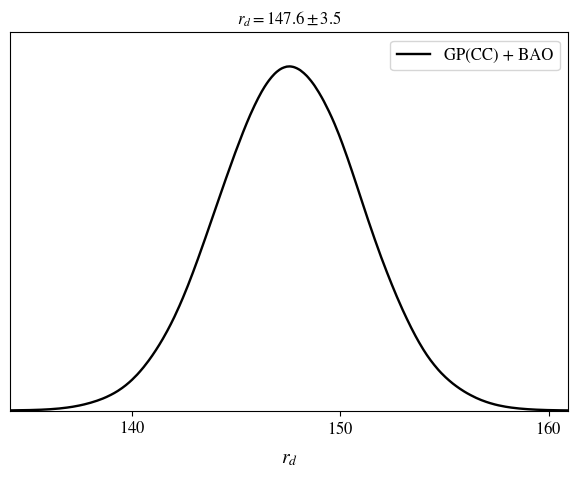

In [17]:
# ============================================================
# Posterior Visualization using GetDist
# ============================================================

param_names  = ["rd"]
param_labels = [r"r_d"]

samples = MCSamples(
    samples=flat_samples,
    names=param_names,
    labels=param_labels,
    label="GP + BAO"
)

samples.updateSettings({
    "smooth_scale_1D": 0.25,
    "fine_bins": 1024
})

g = plots.get_single_plotter()
g.fig.set_size_inches(6, 5)

g.settings.axes_fontsize = 12
g.settings.lab_fontsize = 14
g.settings.legend_fontsize = 12
g.settings.linewidth_contour = 1.5
g.settings.axis_marker_lw = 1.0
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.plot_1d(samples, "rd", filled=True, title_limit=1)

ax = g.subplots[0,0]
ax.patch.set_alpha(0)              # remove white background patch
ax.spines['top'].set_visible(True) # ensure top border is clean
ax.spines['right'].set_visible(True) # ensure right border is clean

g.add_legend(["GP(CC) + BAO"], legend_loc="best")

plt.tight_layout()

plt.savefig("Corner_gp_matern92_rd_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
# =============================================================================
# Marginalized Statistics Extraction for rd
# =============================================================================

stats = samples.getMargeStats().parWithName('rd')

mean_rd = stats.mean
err_rd  = stats.err

limit_95_lower = stats.limits[1].lower
limit_95_upper = stats.limits[1].upper

print(" "*50)
print("="*50)
print(f" FINAL INFERENCE RESULTS (Model-Independent) ")
print("="*50)
print(" "*50)
print(f"Sound Horizon rd: {mean_rd:.3f} ± {err_rd:.3f} Mpc (68% CL)")
print(f"95% CL Interval : [{limit_95_lower:.3f}, {limit_95_upper:.3f}] Mpc")
print(" "*50)
print("="*50)

latex_value = f"r_d = {mean_rd:.2f} \pm {err_rd:.2f}"
display(Math(f"\\text{{Inferred Sound Horizon: }} {latex_value} \\text{{ Mpc}}"))
print(" "*50)

                                                  
 FINAL INFERENCE RESULTS (Model-Independent) 
                                                  
Sound Horizon rd: 147.575 ± 3.458 Mpc (68% CL)
95% CL Interval : [140.787, 154.355] Mpc
                                                  


<IPython.core.display.Math object>

In [19]:
# =============================================================================
# MCMC Convergence Diagnostics (Autocorrelation & Gelman-Rubin)
# =============================================================================

def gelman_rubin_diagnostic(chain_sample):
    
    n_steps, n_walkers, _ = chain_sample.shape
    
    chain_means = np.mean(chain_sample, axis=0)
    grand_mean = np.mean(chain_means, axis=0)
    B = (n_steps / (n_walkers - 1)) * np.sum((chain_means - grand_mean)**2, axis=0)
    
    chain_vars = np.var(chain_sample, axis=0, ddof=1)
    W = np.mean(chain_vars, axis=0)
    
    V_hat = ((n_steps - 1) / n_steps) * W + (B / n_steps)
    R_hat = np.sqrt(V_hat / W)
    
    return R_hat


# -------------------------------------------------------------------
# Execution and Calculations
# -------------------------------------------------------------------

# Autocorrelation Time (tau)
tau_array = sampler.get_autocorr_time(quiet=True)
tau = tau_array[0]
n_eff = nsteps - nburn
converged_tau = n_eff > 50 * tau

# Gelman-Rubin (R-hat)
r_hat = gelman_rubin_diagnostic(chain[nburn:, :, :])


# -------------------------------------------------------------------
# Output Summary
# -------------------------------------------------------------------

print("\n" + "="*55)
print(f"{'MCMC CONVERGENCE SUMMARY':^55}")
print("="*55)

# Autocorrelation Block
print(f"{'Autocorrelation Time (τ):':<35} {tau:>10.2f} steps")
print(f"{'Safety Factor (n_eff / τ):':<35} {n_eff / tau:>10.2f}x")
status_tau = "PASSED" if converged_tau else "FAILED"
print(f"{'Status (Safety Factor > 50):':<35} {status_tau:>10}")

print("-" * 55)

# Gelman-Rubin Block
print(f"{'Gelman-Rubin (R-hat):':<35} {r_hat[0]:>10.4f}")
status_rhat = "PASSED" if r_hat[0] < 1.01 else "FAILED"
print(f"{'Status (R-hat < 1.01):':<35} {status_rhat:>10}")

print("="*55 + "\n")


               MCMC CONVERGENCE SUMMARY                
Autocorrelation Time (τ):                26.76 steps
Safety Factor (n_eff / τ):              560.61x
Status (Safety Factor > 50):            PASSED
-------------------------------------------------------
Gelman-Rubin (R-hat):                   1.0008
Status (R-hat < 1.01):                  PASSED



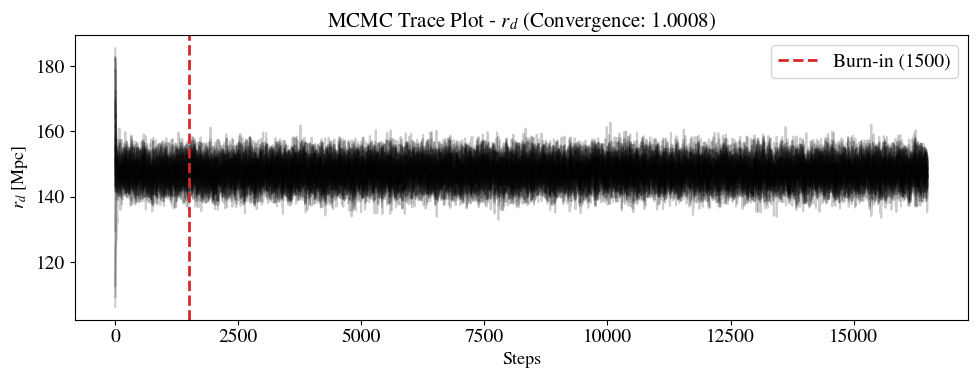

In [20]:
# =============================================================================
# Trace plot for the sound horizon (rd) parameter
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 4))

# Plot the trajectory of each walker for rd
# The chain has the shape (steps, walkers, parameters)
# chain[:, :, 0] accesses all steps and walkers for the first parameter (rd)
ax.plot(chain[:, :, 0], color="k", alpha=0.2)

# Vertical line marking the end of the burn-in phase
# Samples before this line are discarded to remove initial bias
ax.axvline(nburn, color="#d62728", linestyle="--", lw=2, label=f"Burn-in ({nburn})")

# Title displaying the R-hat convergence diagnostic
ax.set_title(f"MCMC Trace Plot - $r_d$ (Convergence: {r_hat[0]:.4f})", fontsize=15)
ax.set_xlabel("Steps", fontsize=13)
ax.set_ylabel("$r_d$ [Mpc]", fontsize=13)

# Place legend to identify the burn-in threshold
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [21]:
# =============================================================================
# Model Selection & Quality of Fit (Model-Independent)
# =============================================================================

# Finding the best-fit (maximum log-likelihood)
log_prob_samples = sampler.get_log_prob(discard=nburn, flat=True)
max_log_like = np.max(log_prob_samples)

# Number of free parameters (k) and observations (N)
k = ndim  # k = 1 (rd)
N = len(d_obs)

# AIC & BIC
aic = 2*k - 2*max_log_like
bic = k * np.log(N) - 2*max_log_like

# Best-fit Chi-square
# Note: Log-likelihood = -0.5 * chi2 + constant
# To get the exact chi2, we calculate it at the best-fit rd
best_theta = flat_samples[np.argmax(log_prob_samples)]
best_rd = best_theta[0]

# Simplified chi2 from the log-likelihood definition:
chi2_min = -2 * max_log_like - N * np.log(2*np.pi) 
red_chi2 = chi2_min / (N - k)

print("\n" + "="*50)
print(f"{'STATISTICAL QUALITY OF RECONSTRUCTION':^50}")
print("="*50)
print(f"{'Best-fit rd:':<35} {best_rd:>10.2f} Mpc")
print(f"{'Reduced χ² (χ²/dof):':<35} {red_chi2:>10.2f}")
print("-" * 50)
print(f"{'Akaike Information (AIC):':<35} {aic:>10.2f}")
print(f"{'Bayesian Information (BIC):':<35} {bic:>10.2f}")
print("="*50 + "\n")


      STATISTICAL QUALITY OF RECONSTRUCTION       
Best-fit rd:                            147.57 Mpc
Reduced χ² (χ²/dof):                     -1.24
--------------------------------------------------
Akaike Information (AIC):                 9.81
Bayesian Information (BIC):              10.21

